In [1]:
import pandas as pd
import geopandas as gpd
import seaborn as sns

import matplotlib.pyplot as plt
from dotenv import load_dotenv
from src.operations.connections import _get_pasta_data
from typing import Tuple, Dict
import os
import xml.etree.ElementTree as ET
from pathlib import Path

import src.inputs.config as cfg
from src.helpers import parse_edges

In [2]:
load_dotenv()  # reads variables from a .env file and sets them in os.environ
connection_strings = {
    "ista": os.getenv("ISTA_URL"),
    "istc": os.getenv("ISTC_URL"),
}
anagrafica, flows = _get_pasta_data(connection_strings['ista'], connection_strings['istc'])

gdf_sens = gpd.GeoDataFrame(
    anagrafica,
    geometry=gpd.points_from_xy(anagrafica.lon, anagrafica.lat),
    crs="EPSG:4326",
).to_crs(epsg=3857)

#gdf_sens['shape'] = (gdf_sens.geometry)
gdf_sens

,Cod_sens,sezione,name,strada,direction,sensor_description,lat,lon,disponibile,geometry
0,417,2,Francia / Massaua,c.Francia,centro,3475178611,45.074371,7.615753,True,POINT (847781.746 5633237.287)
1,428,2,Francia / Marche,c.Francia,centro,3477966219,45.074194,7.612636,True,POINT (847434.763 5633209.385)
2,1009,107,TRR01 - TRAPANI/PESCHIERA\r\n,Corso Trapani,verso Corso Lecce,sensore ENGINE,45.068710,7.638480,True,POINT (850311.704 5632344.963)
3,1010,108,TRR02 - TRAPANI/PESCHIERA\r\n,Corso Peschiera,verso esterno città,sensore ENGINE,45.068830,7.638840,True,POINT (850351.779 5632363.877)
4,1011,109,TRR03 - TRAPANI/PESCHIERA\r\n,Corso Peschiera,verso centro città,sensore ENGINE,45.069020,7.638170,True,POINT (850277.195 5632393.825)
5,1012,110,TRR04 - TRAPANI/PESCHIERA\r\n,Corso Trapani,verso Corso Siracusa,sensore ENGINE,45.069130,7.638550,True,POINT (850319.496 5632411.163)
6,1013,111,LEA01 - LECCE/APPIO CLAUDIO\r\n,Corso Lecce,verso Corso Trapani,sensore ENGINE,45.085110,7.649940,True,POINT (851587.425 5634930.28)
7,1014,112,LEA02 - LECCE/APPIO CLAUDIO\r\n,Corso Lecce,verso Corso Potenza,sensore ENGINE,45.084670,7.649810,True,POINT (851572.954 5634860.908)
8,73191,10701011,B0711 Telesio / Francia,corso Telesio,NORD,sensore FEP_BRIDGE,45.075090,7.624580,True,POINT (848764.363 5633350.626)
9,73192,10701031,B0713 Brunelleschi / Francia,corso Brunelleschi,SUD,sensore FEP_BRIDGE,45.074400,7.623590,True,POINT (848654.157 5633241.858)


In [3]:
tree = ET.parse("/home/marta/tesi-5t/DTBaldissera/vm-file/project/scripts/output/marouter-workdir/MA_no_TLS_DAY/netload_ouput.xml")
root = tree.getroot()

rows = []

for t in root.findall("interval"):
    begin = t.attrib.get("begin")
    end = t.attrib.get("end")

    for e in t.findall("edge"):
        rows.append({
            "begin": begin,
            "end": end,
            "id": e.attrib.get("id"),
            "traveltime": float(e.attrib.get("traveltime")),
            "speed": float(e.attrib.get("speed")),
            "speedRelative": float(e.attrib.get("speedRelative")),
            "entered": float(e.attrib.get("entered")),
            "density": float(e.attrib.get("density")),
            "laneDensity": float(e.attrib.get("laneDensity")),
            "flowCapacityRatio": float(e.attrib.get("flowCapacityRatio")),
        })

df_netload = pd.DataFrame(rows)
df_netload

,begin,end,id,traveltime,speed,speedRelative,entered,density,laneDensity,flowCapacityRatio
0,0.00,3600.00,-104183437,3.30,5.56,1.0,0.0,0.0,0.0,0.0
1,0.00,3600.00,-104183444,4.18,5.56,1.0,0.0,0.0,0.0,0.0
2,0.00,3600.00,-104183448,2.24,5.56,1.0,0.0,0.0,0.0,0.0
3,0.00,3600.00,-1062120746,3.88,5.56,1.0,0.0,0.0,0.0,0.0
4,0.00,3600.00,-106837756,6.39,13.89,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
60691,82800.00,86400.00,952537916#1,4.22,5.56,1.0,0.0,0.0,0.0,0.0
60692,82800.00,86400.00,952537916#2,5.21,5.56,1.0,0.0,0.0,0.0,0.0
60693,82800.00,86400.00,99754717#0,6.33,13.89,1.0,0.0,0.0,0.0,0.0
60694,82800.00,86400.00,99754717#1,10.32,13.89,1.0,0.0,0.0,0.0,0.0


Text(0.5, 1.0, 'Density vs speed')

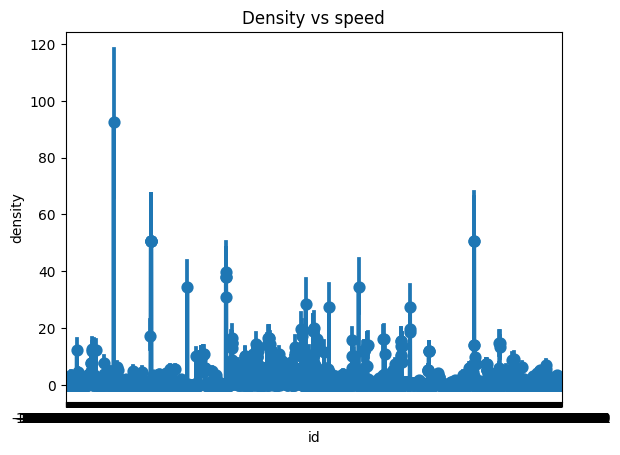

In [4]:
sns.pointplot(data=df_netload, x="id", y="density")
plt.title("Density vs speed")

## GEH index

In [5]:
SCALE_BY = 0.6
flows['count_all'] = flows['count_all'] * SCALE_BY
hour_mean_flows = pd.DataFrame(flows.groupby(by=['Cod_sens', 'hour'])['count_all'].mean())
hour_mean_flows

count_all
Cod_sens hour           
192      0          0.00
         1          0.00
         2          1.00
         3          0.84
         4          1.00
...                  ...
130233   19        16.08
         20        13.84
         21         8.00
         22         5.80
         23         6.36

[13838 rows x 1 columns]

In [6]:
sensor_lane_lookup = pd.read_csv(cfg.SENS_LANE_LOOKUP)

In [8]:
# edges_to_check = set(sensor_lane_lookup['id_edge'])
edge_sensor = sensor_lane_lookup[["Cod_sens", "id_edge"]].drop_duplicates()
edge_sensor

# df = df_netload.where(df_netload['id'].isin(edges_to_check))
df_filtered = df_netload[df_netload['id'].isin(edge_sensor['id_edge'])].reset_index(drop=True)
df_filtered

,begin,end,id,traveltime,speed,speedRelative,entered,density,laneDensity,flowCapacityRatio
0,0.00,3600.00,-1307179596,5.75,21.50,0.97,24.00,0.31,0.10,1.00
1,0.00,3600.00,-1307179610#2,0.09,20.65,0.93,54.74,0.74,0.25,2.28
2,0.00,3600.00,121952543#1,7.62,20.97,0.94,43.00,0.57,0.19,1.79
3,0.00,3600.00,121952544#1,11.47,19.06,0.86,79.63,1.16,0.58,4.98
4,0.00,3600.00,121952560#1,13.74,20.67,0.93,36.00,0.48,0.24,2.25
...,...,...,...,...,...,...,...,...,...,...
451,82800.00,86400.00,1311410663#0,26.43,11.11,1.00,0.00,0.00,0.00,0.00
452,82800.00,86400.00,134420434#1,0.90,16.95,0.87,70.66,1.16,0.58,4.42
453,82800.00,86400.00,257357078#0,0.48,13.89,1.00,0.00,0.00,0.00,0.00
454,82800.00,86400.00,38319544#26,1.77,17.62,0.91,49.59,0.78,0.39,3.10


In [9]:
df_merged = df_filtered.merge(edge_sensor, left_on="id", right_on="id_edge")
df_merged

,begin,end,id,traveltime,speed,speedRelative,entered,density,laneDensity,flowCapacityRatio,Cod_sens,id_edge
0,0.00,3600.00,-1307179596,5.75,21.50,0.97,24.00,0.31,0.10,1.00,73199,-1307179596
1,0.00,3600.00,-1307179610#2,0.09,20.65,0.93,54.74,0.74,0.25,2.28,1011,-1307179610#2
2,0.00,3600.00,121952543#1,7.62,20.97,0.94,43.00,0.57,0.19,1.79,417,121952543#1
3,0.00,3600.00,121952544#1,11.47,19.06,0.86,79.63,1.16,0.58,4.98,73193,121952544#1
4,0.00,3600.00,121952560#1,13.74,20.67,0.93,36.00,0.48,0.24,2.25,73196,121952560#1
...,...,...,...,...,...,...,...,...,...,...,...,...
571,82800.00,86400.00,134420434#1,0.90,16.95,0.87,70.66,1.16,0.58,4.42,73191,134420434#1
572,82800.00,86400.00,257357078#0,0.48,13.89,1.00,0.00,0.00,0.00,0.00,1013,257357078#0
573,82800.00,86400.00,257357078#0,0.48,13.89,1.00,0.00,0.00,0.00,0.00,1014,257357078#0
574,82800.00,86400.00,38319544#26,1.77,17.62,0.91,49.59,0.78,0.39,3.10,95577,38319544#26


In [10]:
import numpy as np

def geh_index(df_sim, df_real, name, metric="entered"):
    df_sim_copy = df_sim.dropna(subset=[metric]).copy()
    
    df_sim_copy["begin"] = pd.to_numeric(df_sim_copy["begin"], errors="coerce")
    df_sim_copy[metric]  = pd.to_numeric(df_sim_copy[metric],  errors="coerce")
    
    df_sim_copy["hour"] = (df_sim_copy["begin"] // 3600).astype(int)
    
    df_sim_copy["hour"] = (df_sim_copy["begin"] // 3600).astype(int)
    
    # se un sensore mappa su più edge somma i veicoli, fa media per la speed
    agg_func = "sum" if metric == "entered" else "mean"
    df_sim_hourly = df_sim_copy.groupby("hour")[metric].agg(agg_func)

    df_real_filtered = df_real.xs(key=name, level="Cod_sens")

    df_sim_hourly, df_real_filtered = df_sim_hourly.align(
        df_real_filtered, join="inner"
    )

    sim_val = df_sim_hourly.values.flatten()
    real_val = df_real_filtered.values.flatten()

    geh = np.where(
        (sim_val + real_val) > 0,
        np.sqrt((2 * (sim_val - real_val) ** 2) / (sim_val + real_val)),
        0.0,
    )

    return pd.DataFrame({
        "Cod_sens": name,
        "hour": df_sim_hourly.index.values,
        "Simulated": sim_val,
        "Real": real_val,
        "GEH": geh,
    })

In [11]:
geh_list = []
for name, df_sim in df_merged.groupby("Cod_sens"):
    df_geh = geh_index(df_sim, hour_mean_flows, name, metric="entered")
    geh_list.append(df_geh)

df_geh_all = pd.concat(geh_list, ignore_index=True)
df_geh_all

,Cod_sens,hour,Simulated,Real,GEH
0,417,0,43.00,105.157895,7.221857
1,417,1,17.00,46.326316,5.211712
2,417,2,11.00,28.957895,4.017622
3,417,3,9.00,24.852632,3.853188
4,417,4,22.00,40.484211,3.306974
...,...,...,...,...,...
571,95577,19,161.13,211.230000,3.671734
572,95577,20,112.60,126.210000,1.245509
573,95577,21,72.65,80.460000,0.892615
574,95577,22,67.34,64.740000,0.319941


In [12]:
df_geh['diff'] = df_geh['Simulated'] - df_geh['Real']
bias_orario = df_geh.groupby('hour')['diff'].mean()
bias_orario

hour
0    -15.010000
1     -7.920000
2     -1.260000
3     -4.190000
4     -1.690000
5      8.630000
6     20.300000
7     20.240000
8     -3.440000
9    -18.150000
10   -27.020000
11   -32.340000
12   -26.220000
13    -3.020000
14   -13.420000
15   -36.790000
16   -39.950000
17   -44.136842
18   -56.730000
19   -50.100000
20   -13.610000
21    -7.810000
22     2.600000
23    -1.350000
Name: diff, dtype: float64

In [13]:
ratio = df_geh.groupby('hour').apply(lambda g: g['Simulated'].sum() / g['Real'].sum())
ratio

/tmp/ipykernel_82785/885534608.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ratio = df_geh.groupby('hour').apply(lambda g: g['Simulated'].sum() / g['Real'].sum())


hour
0     0.390581
1     0.274725
2     0.704225
3     0.192678
4     0.747384
5     1.351241
6     1.311828
7     1.108102
8     0.985941
9     0.908596
10    0.853288
11    0.824401
12    0.852215
13    0.980566
14    0.925950
15    0.816280
16    0.825149
17    0.829677
18    0.782619
19    0.762818
20    0.892164
21    0.902933
22    1.040161
23    0.973498
dtype: float64

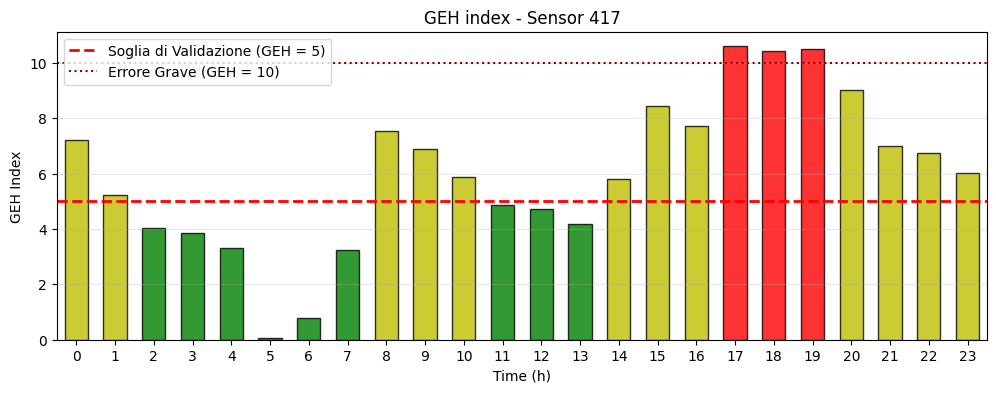

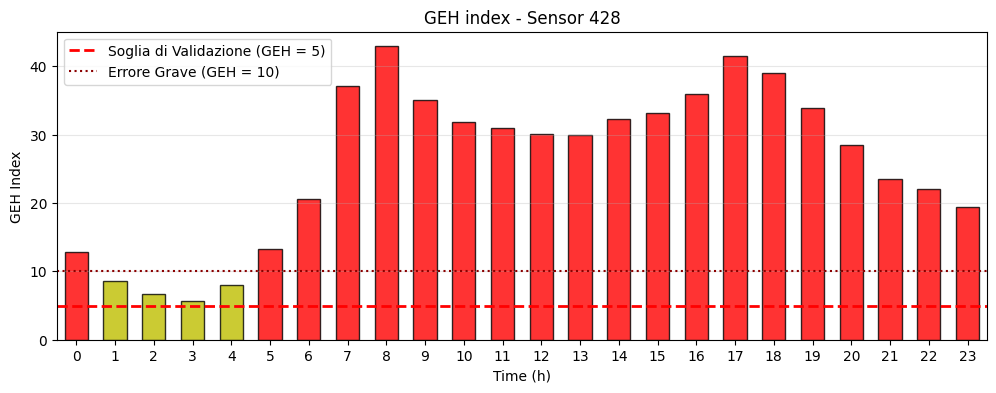

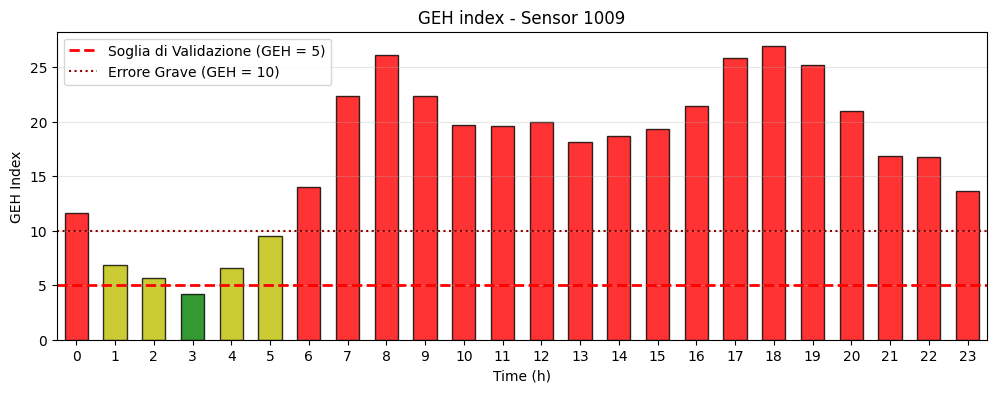

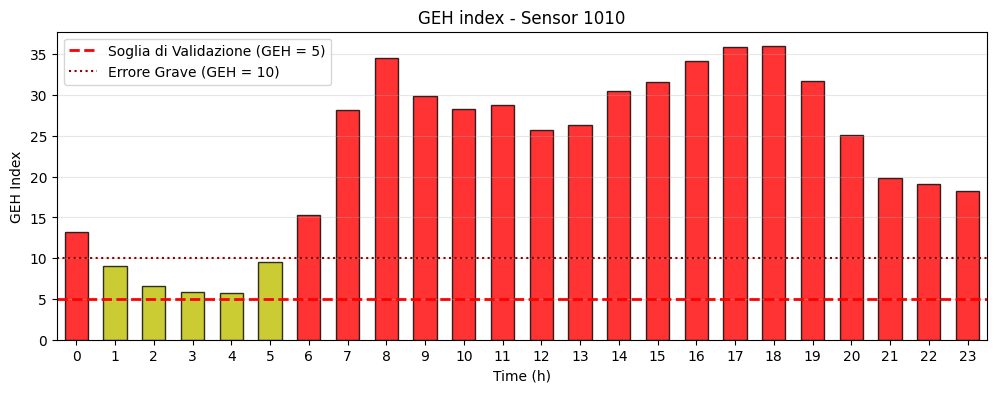

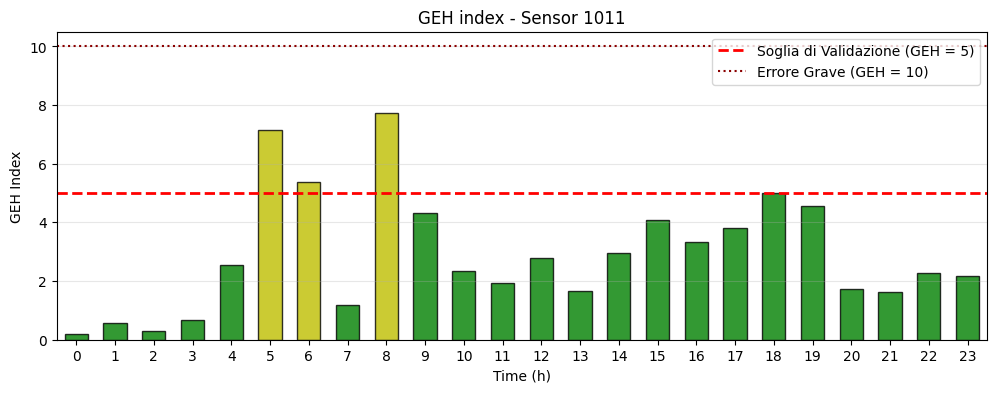

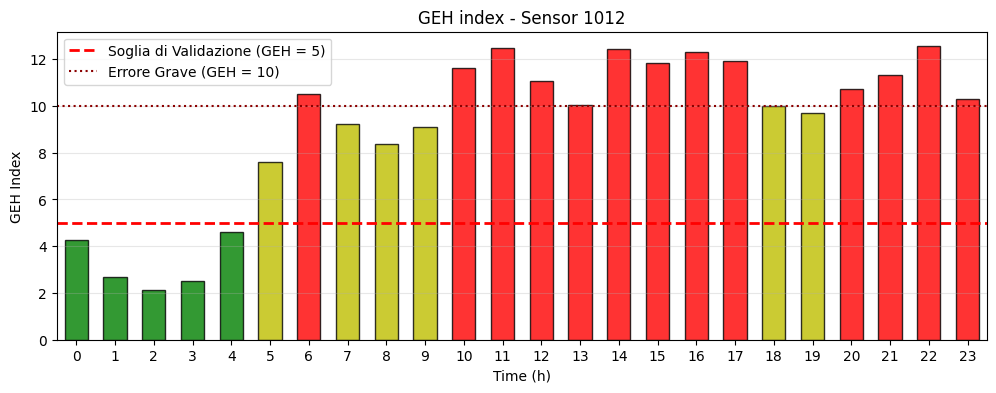

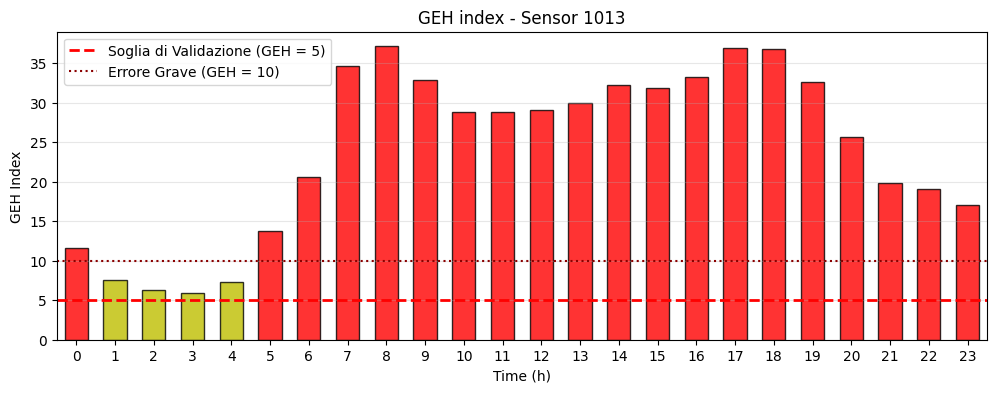

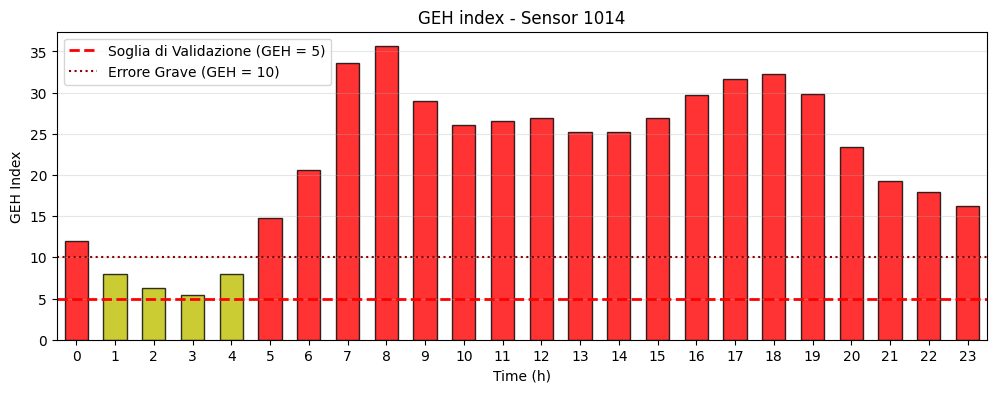

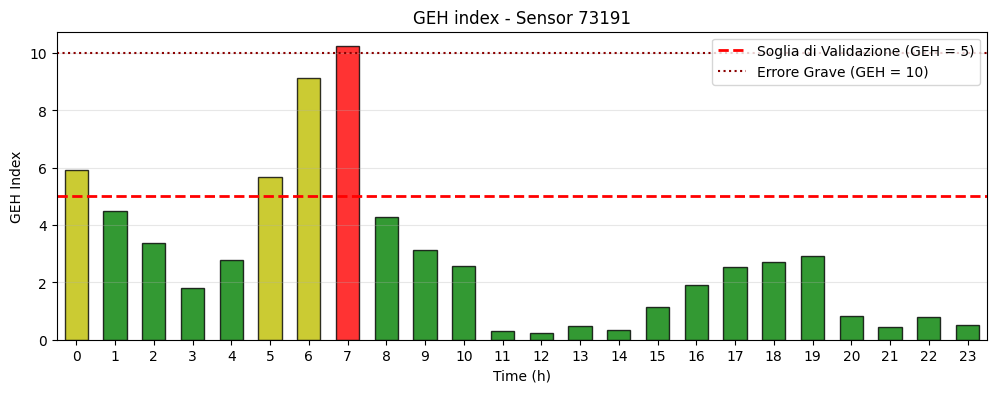

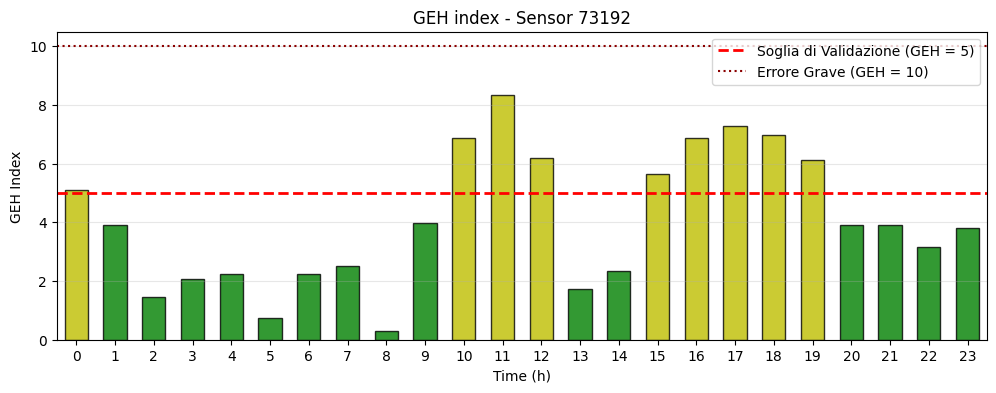

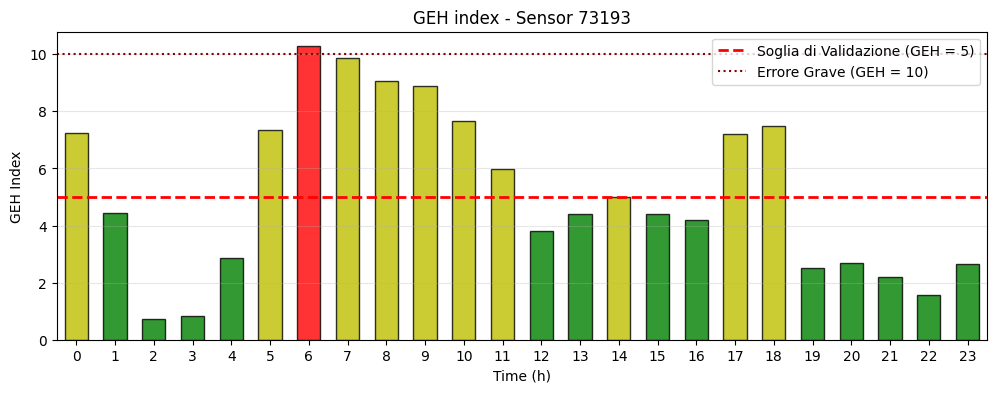

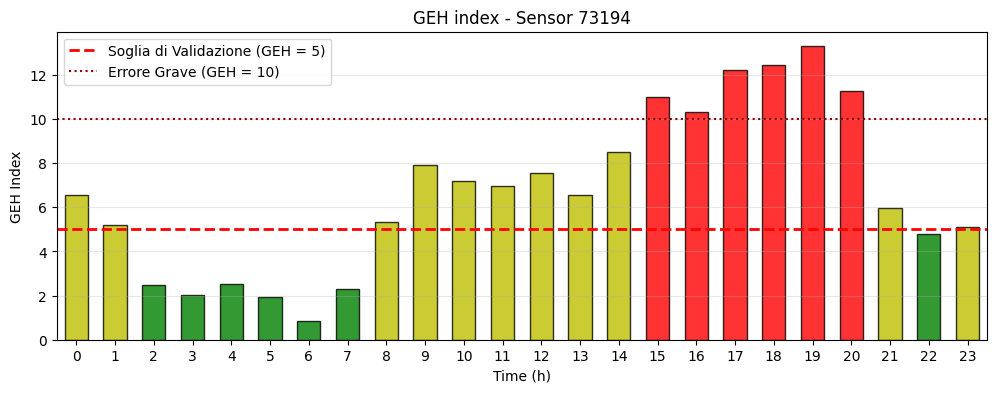

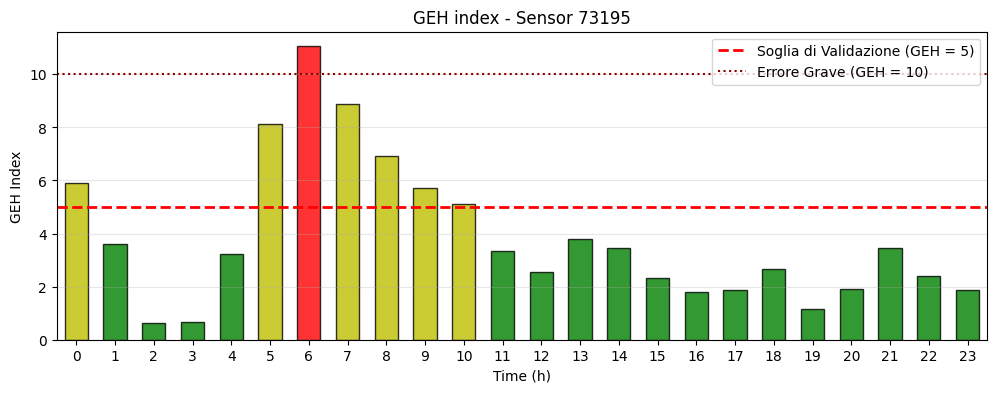

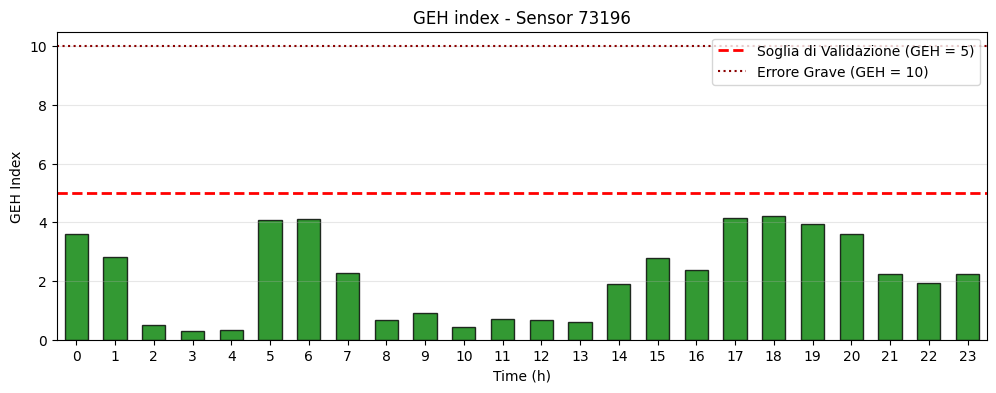

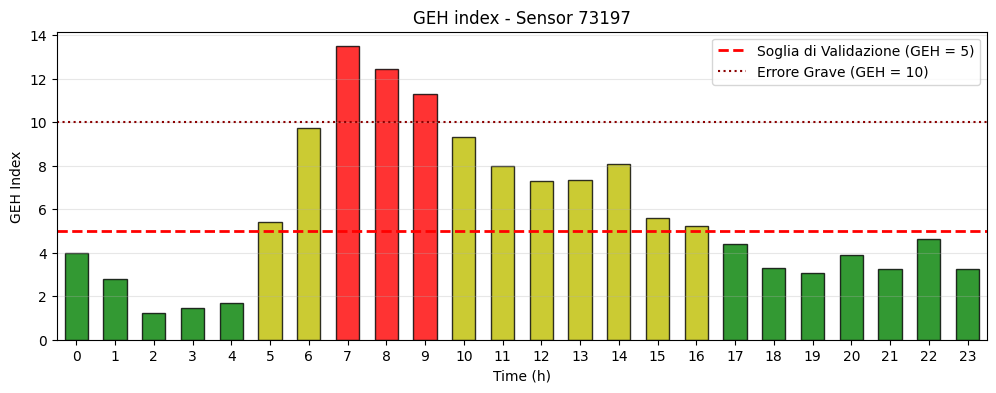

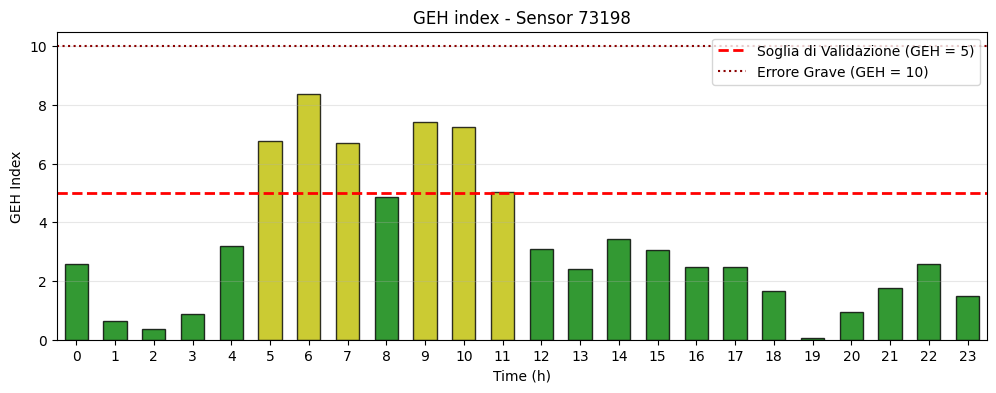

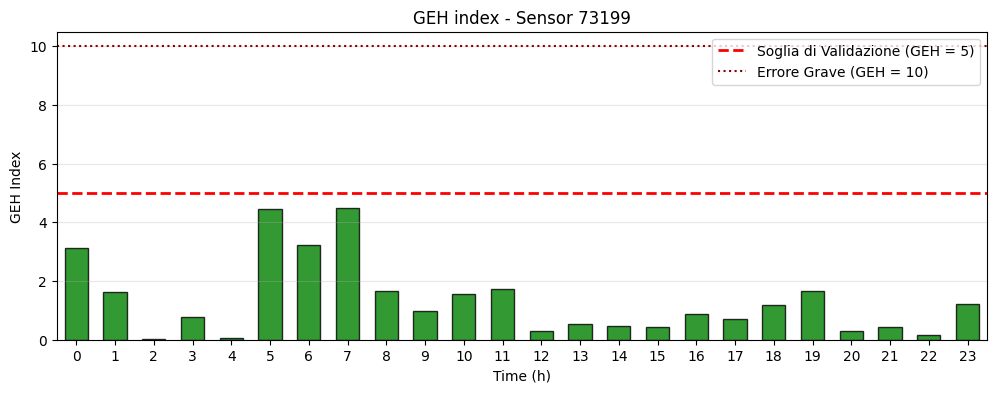

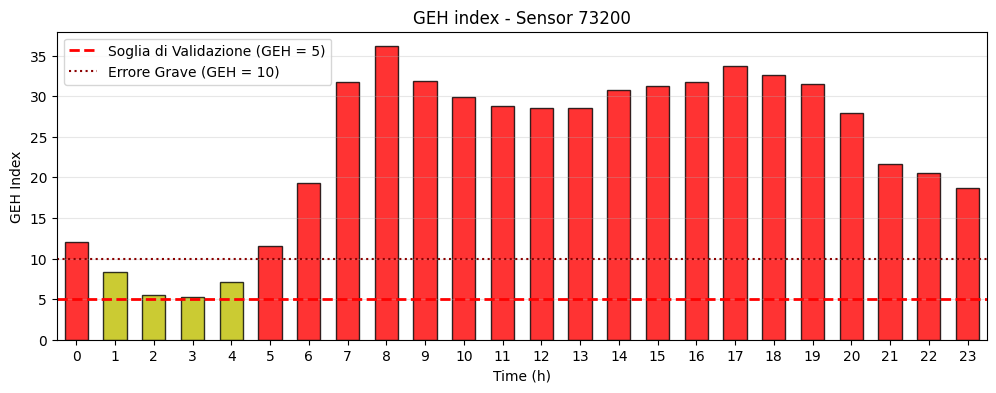

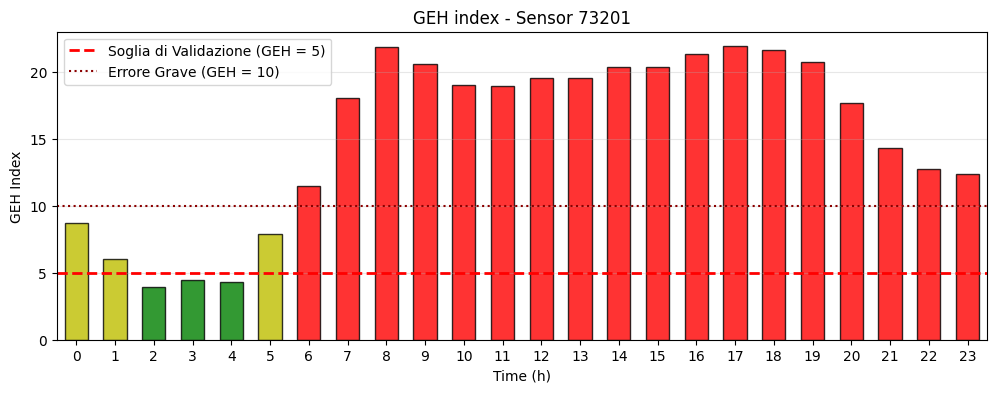

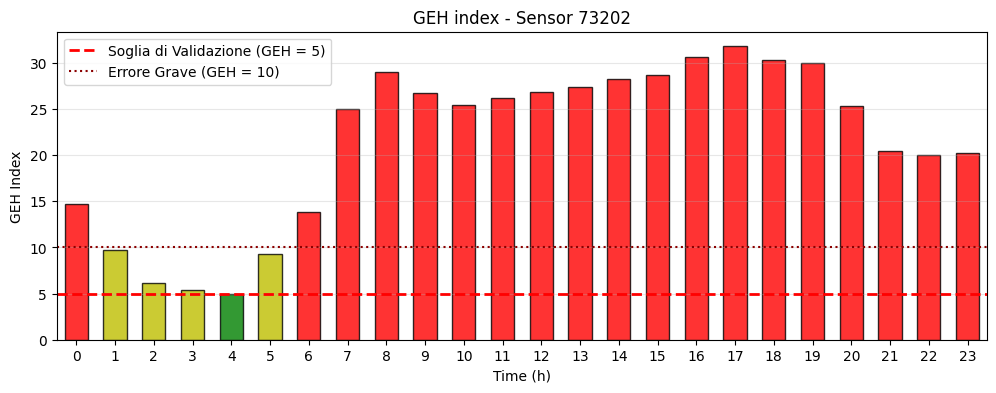

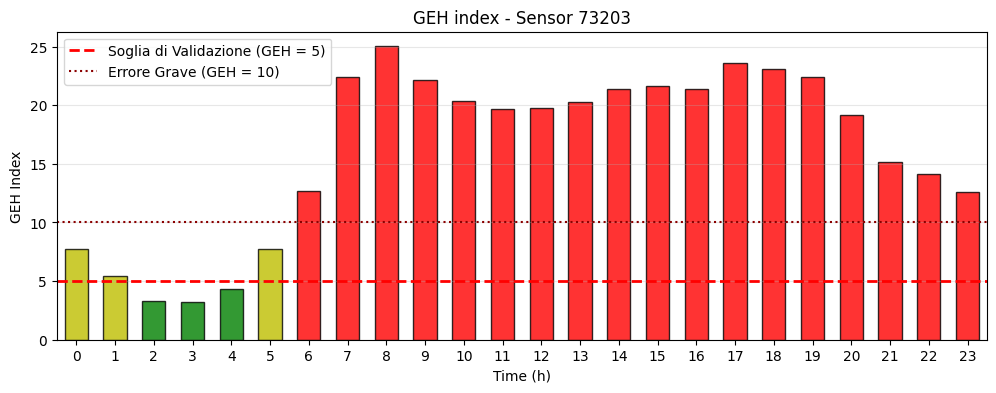

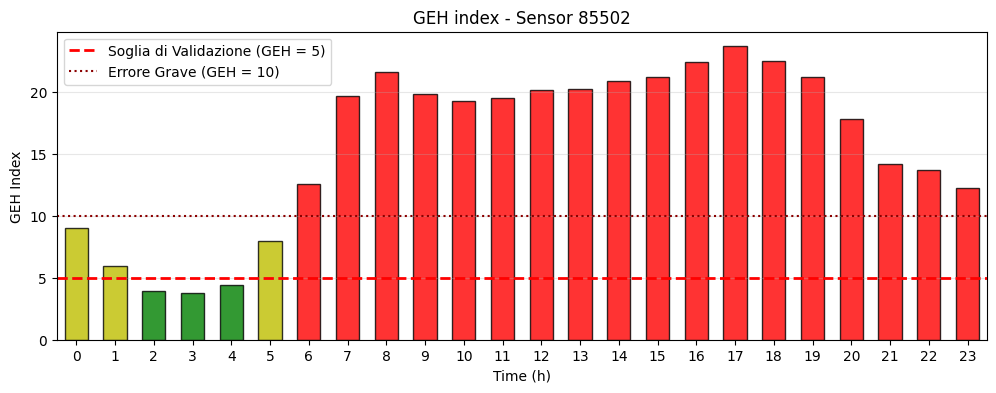

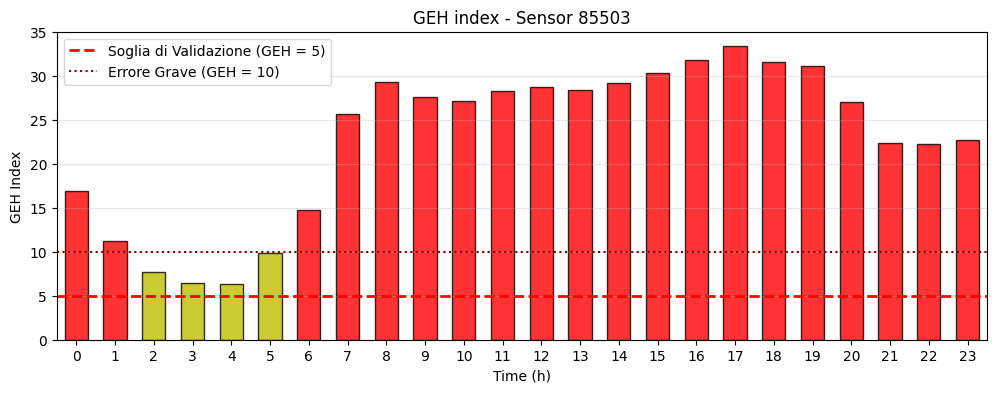

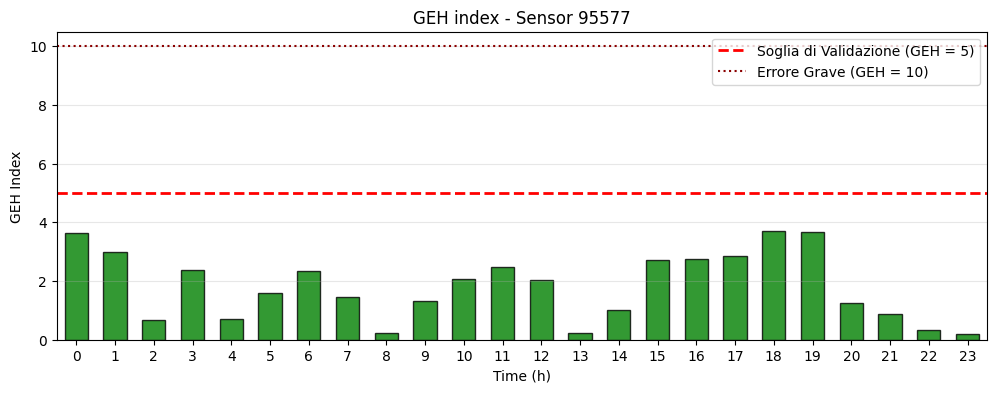

In [14]:
import matplotlib.pyplot as plt

def plot_geh_hourly(df_geh, name):
    """
    Prende in input il DataFrame complessivo di tutti i sensori,
    lo filtra per il sensore specificato e genera un grafico a barre orario del GEH.
    """
    if df_geh is None or df_geh.empty: 
        return
    
    # 1. Filtriamo IMMEDIATAMENTE i dati per il sensore corrente
    df_geh_filtered = df_geh[df_geh['Cod_sens'] == name]
    
    if df_geh_filtered.empty:
        print(f"No data related to GEH index for sensor {name}")
        return

    # 2. Generiamo i colori SOLO sulle righe del sensore filtrato
    colors = ['g' if x < 5 else 'y' if x <= 10 else 'r' for x in df_geh_filtered['GEH']]
    
    plt.figure(figsize=(12, 4))
    
    plt.bar(df_geh_filtered['hour'], df_geh_filtered['GEH'], color=colors, alpha=0.8, edgecolor='black', width=0.6)
    plt.axhline(y=5, color='red', linestyle='--', linewidth=2, label='Soglia di Validazione (GEH = 5)')
    plt.axhline(y=10, color='darkred', linestyle=':', linewidth=1.5, label='Errore Grave (GEH = 10)')
    
    # Formattazione assi
    plt.xlim(-0.5, 23.5)
    plt.xticks(range(0, 24))
    plt.xlabel('Time (h)')
    plt.ylabel('GEH Index')
    plt.title(f'GEH index - Sensor {name}')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.show()

for name, df_geh_sensor in df_geh_all.groupby("Cod_sens"):
    plot_geh_hourly(df_geh_sensor, name)